# **`Inatel - C24 (Inteligência Artificial) - 2026/1`**

# <font color='green'>**Atividade 06: Classificação**</font>

## <font color='#2D9CDB'>**LEIA ATENTAMENTE AS INSTRUÇÕES A SEGUIR**</font>
- Importe este notebook no [Google Colab](https://colab.research.google.com/) para resolver os exercícios;
- Consulte o material disponibilizado pelo Prof. Felipe Figueiredo para revisar os conceitos;
- Utilize os recursos disponíveis na Internet (documentações e artigos científicos) para complementar seus estudos;
- <font color='red'>**A ATIVIDADE DEVERÁ SER REALIZADA COM O [MONITOR](mailto:matheus.botelho@ges.inatel.br) EM UM DOS SEGUINTES HORÁRIOS:**</font>

| Monitor                       | Dia           | Hora                               | Local           |
|-------------------------------|---------------|------------------------------------|---------------- |
| Matheus Botelho Sampaio Netto | Terça-feira   | <font color='orange'>17:30</font>  | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Quinta-feira  | <font color='orange'>17:30</font>  | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Sábado        | <font color='#2D9CDB'>10:00</font> | Teams (ao vivo) |
| Matheus Botelho Sampaio Netto | Sábado        | <font color='#2D9CDB'>13:30</font> | Teams (ao vivo) |

- <font color='red'>**NÃO**</font> remova as células de Código já presentes neste notebook;
- <font color='red'>**NÃO**</font> modifique as células de Markdown (em <font color='green'>verde</font> ou <font color='#2D9CDB'>azul</font>) presentes neste notebook;
- Após cada questão, há uma célula para você implementar e responder a questão;
- É permitido adicionar mais células (de código ou markdown) antes da próxima pergunta;
- Caso precise utilizar bibliotecas que não estão instaladas nativamente no Colab, inclua uma célula de código com o comando de instalação.</font>
  - Exemplo: `!pip install nome_da_biblioteca`
- <font color='red'>**Renomeie os termos `LL` para `sua_turma_de_laboratorio` e `MMMM` para `seu_numero_de_matricula` no nome do arquivo.**</font>
  - Exemplo: `C24_2026_1_L1_Atividade_06_1234.ipynb`)
- <font color='magenta'>**Faça download do notebook com a resolução no Google Colab, mantendo a saída de todas as células, e anexe-o à tarefa do Teams.**</font>

# <font color='green'><u><b>Preparação</b></u></font>

In [206]:
!pip install numpy pandas matplotlib seaborn scikit-learn ucimlrepo

In [207]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# <font color='green'><u><b>Parte 1 - Classificação Binária</b></u></font>

### <font color='#2D9CDB'>Acesse o link indicado e, em um único parágrafo, descreva brevemente o dataset, incluindo: domínio de aplicação, objetivo da base de dados e o tipo de informações que ela contém.</font>
- #### <font color='#2D9CDB'>Iranian Churn Dataset (2020). UCI Machine Learning Repository.</font>
  - #### <font color='#2D9CDB'>https://doi.org/10.24432/C5JW3Z</font>
  - #### <font color='#2D9CDB'>https://archive-beta.ics.uci.edu/dataset/563/iranian+churn+dataset</font>

O dataset possui o domínio de Telecomunicações e tem como objetivo entender a variável Churn (cancelamento de serviço), uma vez que o custo de atrair/ganhar novos clientes é maior do que manter os atuais, fazendo predições com essa variável a fim de entender motivos de abandono e rotular clientes. O dataset apresenta informações como falhas em ligações (Call Failures), presença de reclamações (Complains), faixa etária do cliente (Age Group), valor do cliente para a empresa (Customer Value), etc.

In [208]:
# fetch dataset
ds = fetch_ucirepo(id=563)

# metadata
display(ds.metadata)

# variable information
display(ds.variables)

# data (as pandas dataframe)
df = pd.concat([ds.data.features, ds.data.targets], axis='columns')

{'uci_id': 563,
 'name': 'Iranian Churn',
 'repository_url': 'https://archive.ics.uci.edu/dataset/563/iranian+churn+dataset',
 'data_url': 'https://archive.ics.uci.edu/static/public/563/data.csv',
 'abstract': "This dataset is randomly collected from an Iranian telecom company's database over a period of 12 months.",
 'area': 'Business',
 'tasks': ['Classification', 'Regression'],
 'characteristics': ['Multivariate'],
 'num_instances': 3150,
 'num_features': 13,
 'feature_types': ['Integer'],
 'demographics': ['Age'],
 'target_col': ['Churn'],
 'index_col': None,
 'has_missing_values': 'no',
 'missing_values_symbol': None,
 'year_of_dataset_creation': 2020,
 'last_updated': 'Sat Mar 09 2024',
 'dataset_doi': '10.24432/C5JW3Z',
 'creators': [],
 'intro_paper': None,
 'additional_info': {'summary': 'This dataset is randomly collected from an Iranian telecom companyâ€™s database over a period of 12 months. A total of 3150 rows of data, each representing a customer, bear information for 13

,name,role,type,demographic,description,units,missing_values
0,Call Failure,Feature,Integer,None,None,None,no
1,Complains,Feature,Binary,None,None,None,no
2,Subscription Length,Feature,Integer,None,None,None,no
3,Charge Amount,Feature,Integer,None,None,None,no
4,Seconds of Use,Feature,Integer,None,None,None,no
5,Frequency of use,Feature,Integer,None,None,None,no
6,Frequency of SMS,Feature,Integer,None,None,None,no
7,Distinct Called Numbers,Feature,Integer,None,None,None,no
8,Age Group,Feature,Integer,Age,None,None,no
9,Tariff Plan,Feature,Integer,None,None,None,no


### <font color='#2D9CDB'>Q1) Exiba as primeiras linhas do dataframe, verifique suas dimensões e identifique a variável alvo (`TARGET_COLUMN`), respondendo com base nos resultados obtidos: quantas amostras e atributos o dataset possui, qual é o nome da variável alvo e se o problema é de classificação binária (justifique observando os valores únicos da variável alvo).</font>

In [209]:
display(df.head(10))

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640,0
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035,0
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520,0
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020,0
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805,0
5,11,0,38,1,3775,82,32,28,3,1,1,30,282.280,0
6,4,0,38,0,2360,39,285,18,3,1,1,30,1235.960,0
7,13,0,37,2,9115,121,144,43,3,1,1,30,945.440,0
8,7,0,38,0,13773,169,0,44,3,1,1,30,557.680,0
9,7,0,38,1,4515,83,2,25,3,1,1,30,191.920,0


In [210]:
display(df.shape)

(3150, 14)

In [211]:
TARGET_COLUMN = 'Churn'

O dataset possui 3150 amostras e 14 atributos (incluindo a variável alvo), sendo Churn a variável alvo; trata-se de um problema de classificação binária, pois essa variável assume apenas dois valores (0 e 1), indicando respectivamente clientes que não cancelaram e que cancelaram o serviço.

### <font color='#2D9CDB'>Q2) Plote a distribuição da variável alvo utilizando o gráfico fornecido e, com base no resultado obtido, analise a proporção entre as classes para determinar se o dataset é balanceado ou desbalanceado, justificando sua resposta a partir da contagem de amostras em cada classe.</font>

[]

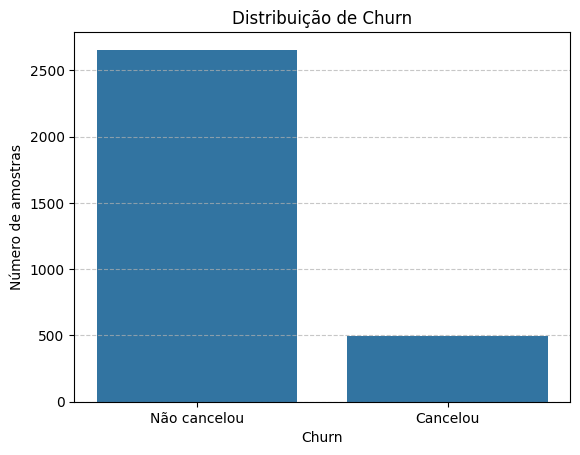

In [212]:
sns.countplot(x=TARGET_COLUMN, data=df)
plt.title('Distribuição de Churn')
plt.xlabel('Churn')
plt.ylabel('Número de amostras')
plt.xticks(ticks=[0, 1], labels=['Não cancelou', 'Cancelou'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.plot()

In [213]:
print(f'Número de amostras com Churn = 0: {len(df[df[TARGET_COLUMN] == 0])}')
print(f'Número de amostras com Churn = 1: {len(df[df[TARGET_COLUMN] == 1])}')
print(f'Razão entre as classes: {(len(df[df[TARGET_COLUMN] == 0]) / len(df[df[TARGET_COLUMN] == 1])):.2f}')

Número de amostras com Churn = 0: 2655
Número de amostras com Churn = 1: 495
Razão entre as classes: 5.36


Baseado na análise da diferença na quantidade entre as classes, pode-se dizer que o dataset é desbalanceado (o que pode ser visto pela razão da retenção dos usuários).

### <font color='#2D9CDB'>Q3) Gere a matriz de correlação entre os atributos do dataset e a variável alvo utilizando o gráfico fornecido e, com base nos valores apresentados, identifique quais atributos possuem maior correlação (positiva ou negativa) com a variável alvo, indicando quais podem ser mais relevantes para o problema de classificação.</font>

In [214]:
df.corrwith(df[TARGET_COLUMN]).drop(TARGET_COLUMN)

,0
Call Failure,-0.008987
Complains,0.532053
Subscription Length,-0.032588
Charge Amount,-0.202305
Seconds of Use,-0.298935
Frequency of use,-0.303337
Frequency of SMS,-0.220754
Distinct Called Numbers,-0.278867
Age Group,-0.014550
Tariff Plan,-0.105853


In [215]:
top_corr = df.corrwith(df[TARGET_COLUMN]).abs().drop(TARGET_COLUMN).idxmax()
print(f'O atributo com maior correlação com a variável alvo é {top_corr}')

bottom_corr = df.corrwith(df[TARGET_COLUMN]).abs().drop(TARGET_COLUMN).idxmin()
print(f'O atributo com menor correlação com a variável alvo é {bottom_corr}')

O atributo com maior correlação com a variável alvo é Complains
O atributo com menor correlação com a variável alvo é Call  Failure


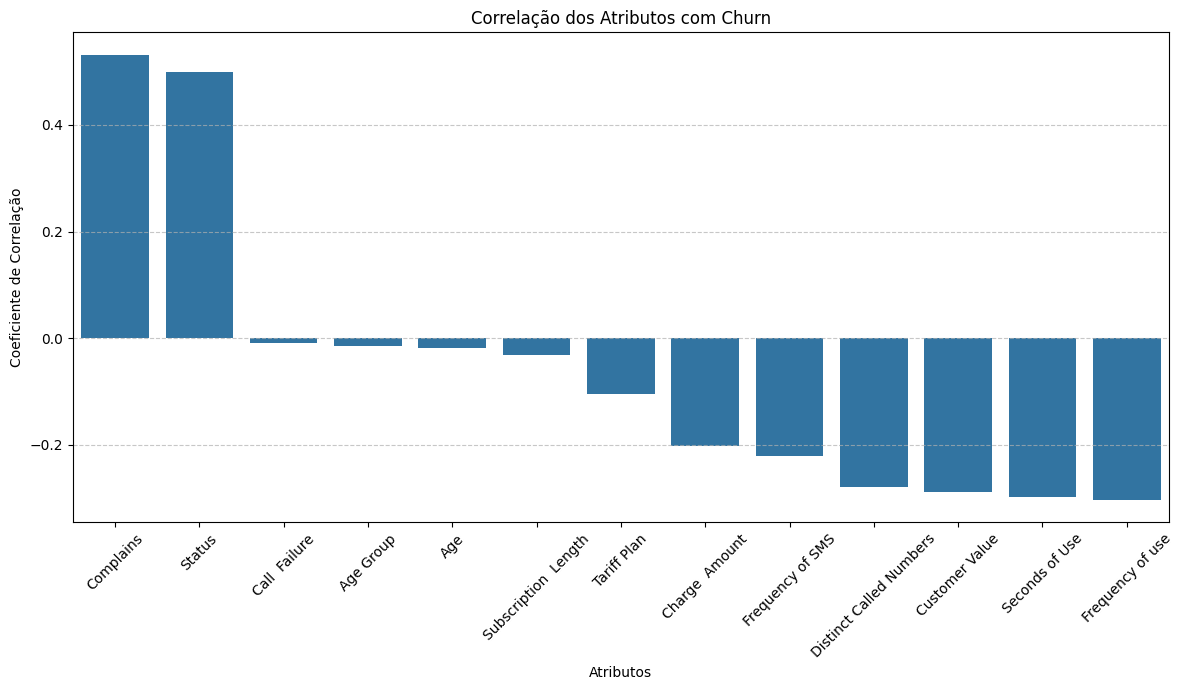

In [216]:
correlations = df.corrwith(df[TARGET_COLUMN]).drop(TARGET_COLUMN).sort_values(ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x=correlations.index, y=correlations.values)
plt.title('Correlação dos Atributos com Churn')
plt.xlabel('Atributos')
plt.ylabel('Coeficiente de Correlação')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Com base nos resultados, os atributos com maior correlação (positiva ou negativa) com a variável alvo Churn são Complains (correlação positiva de ~0.53) e Status(correlação positiva de ~0.50). Esses atributos indicam uma forte relação com a decisão de churn do cliente e, portanto, podem ser mais relevantes para o problema de classificação. Em contrapartida, Age Group, Age e Call Failure possuem correlações muito próximas de zero, o que sugere uma baixa relevância para prever o churn.

### <font color='#2D9CDB'>Q4) Aplique a técnica de Análise de Componentes Principais (PCA) para projetar os dados em duas dimensões e gere um gráfico de dispersão (scatter plot) utilizando as duas primeiras componentes principais, colorindo os pontos de acordo com a variável alvo; antes de aplicar o PCA, padronize os dados utilizando `StandardScaler`; em seguida, com base na visualização obtida, analise se há separação entre as classes e justifique sua resposta considerando a presença ou não de sobreposição entre os grupos.</font>

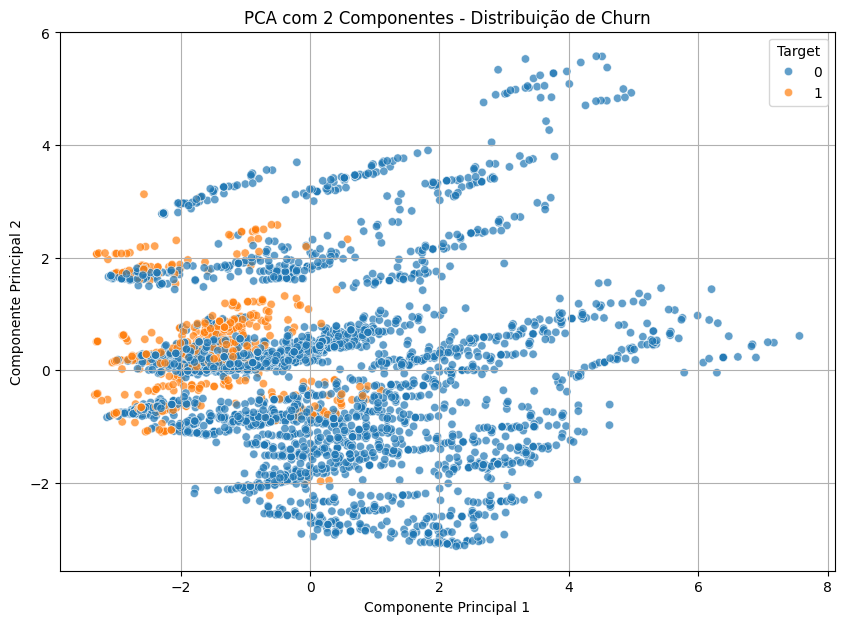

In [217]:
X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
pca_df['Target'] = y.reset_index(drop=True)

plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', hue='Target', data=pca_df, alpha=0.7)
plt.title('PCA com 2 Componentes - Distribuição de Churn')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.grid(True)
plt.show()

A partir do gráfico de dispersão gerado pelas duas primeiras componentes principais, observa-se uma grande sobreposição entre as classes (0 e 1). Os pontos que representam clientes que não deram churn (Target = 0) e os que deram churn (Target = 1) estão bastante misturados, sem uma fronteira de separação clara. Isso indica que, nessas duas dimensões principais, não há uma separação linearmente distinguível entre as classes, sugerindo que o problema de classificação pode ser desafiador com base apenas nessas componentes.

### <font color='#2D9CDB'>Q5) Separe o dataset em variáveis de entrada (`X`) e variável alvo (`y`), divida os dados em conjuntos de treino e teste utilizando `train_test_split` (com 20% para teste) e `random_state=42`, e aplique a padronização dos atributos com `StandardScaler`; em seguida, explique por que a padronização é importante nesse contexto e por que o `fit` deve ser aplicado apenas no conjunto de treino.

In [218]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

A padronização é importante para escalonar os dados em um intervalo mais relevante para análise. O fit deve ser aplicado apenas no conjunto de treino a fim de evitar data leakage (vazamento de dados) para os demais conjuntos do modelo.

### <font color='#2D9CDB'>Q6) Treine um modelo de regressão logística utilizando os dados de treino (`X_train`, `y_train`) e, após o treinamento, verifique se o modelo convergiu corretamente; em seguida, descreva qual é o papel desse modelo no contexto do problema e o que ele está aprendendo a partir dos dados.</font>

In [219]:
# Regressão logística
model = LogisticRegression()
model.fit(X_train, y_train)

print(f'Número de iterações: {model.n_iter_} até a convergência')

Número de iterações: [42] até a convergência


O modelo convergiu para n_iter = 42. O papel desse modelo é estimar a probabilidade de uma amostra pertencer a uma categoria específica (Se o usuário resolveu cancelar o serviço ou não). Ele aprende a relação matemática entre os atributos e a chance do evento ocorrer.

### <font color='#2D9CDB'>Q7) Utilize o modelo treinado para calcular as probabilidades previstas para o conjunto de teste (`predict_proba`) e exiba algumas delas; em seguida, interprete os valores obtidos explicando o que cada coluna representa e analise se o modelo está fazendo previsões com alta ou baixa confiança, com base na proximidade dos valores de 0 e 1.</font>

In [220]:
print(model.predict_proba(X_test)[:10])
print("-"*60)
print(model.predict_proba(X_test)[:,1][:10]) # Apenas para classe 1

[[9.98819220e-01 1.18078042e-03]
 [9.99954113e-01 4.58869561e-05]
 [9.74259483e-01 2.57405165e-02]
 [9.99517602e-01 4.82398265e-04]
 [9.98645143e-01 1.35485663e-03]
 [9.97154922e-01 2.84507844e-03]
 [9.91458577e-01 8.54142300e-03]
 [9.91454963e-01 8.54503750e-03]
 [9.87024986e-01 1.29750142e-02]
 [5.90190333e-01 4.09809667e-01]]
------------------------------------------------------------
[1.18078042e-03 4.58869561e-05 2.57405165e-02 4.82398265e-04
 1.35485663e-03 2.84507844e-03 8.54142300e-03 8.54503750e-03
 1.29750142e-02 4.09809667e-01]


A primeira coluna indica a probabilidade para a classe 0 e a segunda para a classe 1. Como os valores estão próximos das extremidades (1 e 0), o modelo está fazendo previsões com alta confiança.

### <font color='#2D9CDB'>Q8) Utilize as probabilidades previstas para gerar classificações com dois limiares diferentes (0.5 e 0.7) e compare os resultados obtidos; em seguida, analise como a alteração do limiar afeta as previsões do modelo, especialmente em relação à quantidade de falsos positivos e falsos negativos.</font>

In [221]:
proba_positiva = model.predict_proba(X_test)[:,1]
y_pred_05 = (proba_positiva >= 0.5).astype(int)
y_pred_07 = (proba_positiva >= 0.7).astype(int)

print(f'Acurácia com limiar 0.5: {accuracy_score(y_test, y_pred_05)}')
print(f'Acurácia com limiar 0.7: {accuracy_score(y_test, y_pred_07)}')

print(f'Falsos positivos com limiar 0.5: {np.sum((y_test == 0) & (y_pred_05 == 1))}')
print(f'Falsos negativos com limiar 0.5: {np.sum((y_test == 1) & (y_pred_05 == 0))}')

print(f'Falsos positivos com limiar 0.7: {np.sum((y_test == 0) & (y_pred_07 == 1))}')
print(f'Falsos negativos com limiar 0.7: {np.sum((y_test == 1) & (y_pred_07 == 0))}')

Acurácia com limiar 0.5: 0.8698412698412699
Acurácia com limiar 0.7: 0.873015873015873
Falsos positivos com limiar 0.5: 16
Falsos negativos com limiar 0.5: 66
Falsos positivos com limiar 0.7: 6
Falsos negativos com limiar 0.7: 74


O aumento do limiar melhorou a precisão, mas diminuiu a sensibilidade/recall (mais casos positivos ignorados).

### <font color='#2D9CDB'>Q9) Calcule as métricas de desempenho (acurácia, precisão, recall e F1-score) e a matriz de confusão para os dois limiares de decisão (0.5 e 0.7) utilizando a função fornecida e, com base nos resultados obtidos, compare o desempenho do modelo, identificando qual métrica foi mais impactada pela mudança do limiar e discutindo o trade-off observado entre precisão e recall.</font>

In [222]:
print(f'Acurácia com limiar 0.5: {accuracy_score(y_test, y_pred_05)}')
print(f'Acurácia com limiar 0.7: {accuracy_score(y_test, y_pred_07)}')
print('-'*45)
print(f'Precisão com limiar 0.5: {precision_score(y_test, y_pred_05)}')
print(f'Precisão com limiar 0.7: {precision_score(y_test, y_pred_07)}')
print('-'*45)
print(f'Recall com limiar 0.5: {recall_score(y_test, y_pred_05)}')
print(f'Recall com limiar 0.7: {recall_score(y_test, y_pred_07)}')
print('-'*45)
print(f'F1-score com limiar 0.5: {f1_score(y_test, y_pred_05)}')
print(f'F1-score com limiar 0.7: {f1_score(y_test, y_pred_07)}')
print('-'*45)
print(f'Matriz de confusão com limiar 0.5:\n{confusion_matrix(y_test, y_pred_05)}')
print(f'Matriz de confusão com limiar 0.7:\n{confusion_matrix(y_test, y_pred_07)}')


Acurácia com limiar 0.5: 0.8698412698412699
Acurácia com limiar 0.7: 0.873015873015873
---------------------------------------------
Precisão com limiar 0.5: 0.7333333333333333
Precisão com limiar 0.7: 0.8571428571428571
---------------------------------------------
Recall com limiar 0.5: 0.4
Recall com limiar 0.7: 0.32727272727272727
---------------------------------------------
F1-score com limiar 0.5: 0.5176470588235295
F1-score com limiar 0.7: 0.47368421052631576
---------------------------------------------
Matriz de confusão com limiar 0.5:
[[504  16]
 [ 66  44]]
Matriz de confusão com limiar 0.7:
[[514   6]
 [ 74  36]]


As métricas mais afetadas foram Precisão (\~ +0,124) e Recall (\~ -0,073). Em relação ao trade-off, pode-se observar que com o aumento do limiar de 0,5 para 0,7, garante-se maior precisão, mas o recall cai (em um nível menor). O que pode ser explicado pela densidade de probabilidades ser mais confiável acima de 0,7 para classes negativas.

# <font color='green'><u><b>Parte 2 - Classificação Multiclasse</b></u></font>

### <font color='#2D9CDB'>Acesse o link indicado e, em um único parágrafo, descreva brevemente o dataset, incluindo: domínio de aplicação, objetivo da base de dados e o tipo de informações que ela contém.</font>
- #### <font color='#2D9CDB'>Blackard, J. (1998). Covertype Dataset. UCI Machine Learning Repository.</font>
  - #### <font color='#2D9CDB'>https://doi.org/10.24432/C50K5N</font>
  - #### <font color='#2D9CDB'>https://archive-beta.ics.uci.edu/dataset/31/covertype</font>

O dataset apresentado possui o domínio: Biologia. Ele é focado no mapeamento da vegetação da Floresta Nacional de Roosevelt, no Colorado. O objetivo central da base de dados é prever o tipo de cobertura florestal, classificando entre diferentes espécies arbóreas utilizando exclusivamente variáveis cartográficas em vez de dados de sensoriamento remoto. o conjunto contém informações brutas que englobam atributos quantitativos, como elevação, orientação e declividade, além de variáveis qualitativas que representam as quatro áreas de preservação ambiental da região e os diversos tipos de solo mapeados.

In [223]:
# fetch dataset
ds = fetch_ucirepo(id=31)

# metadata
display(ds.metadata)

# variable information
display(ds.variables)

# data (as pandas dataframe)
df = pd.concat([ds.data.features, ds.data.targets], axis='columns').sample(frac=0.10, random_state=42)

{'uci_id': 31,
 'name': 'Covertype',
 'repository_url': 'https://archive.ics.uci.edu/dataset/31/covertype',
 'data_url': 'https://archive.ics.uci.edu/static/public/31/data.csv',
 'abstract': 'Classification of pixels into 7 forest cover types based on attributes such as elevation, aspect, slope, hillshade, soil-type, and more.',
 'area': 'Biology',
 'tasks': ['Classification'],
 'characteristics': ['Multivariate'],
 'num_instances': 581012,
 'num_features': 54,
 'feature_types': ['Categorical', 'Integer'],
 'demographics': [],
 'target_col': ['Cover_Type'],
 'index_col': None,
 'has_missing_values': 'no',
 'missing_values_symbol': None,
 'year_of_dataset_creation': 1998,
 'last_updated': 'Sat Mar 16 2024',
 'dataset_doi': '10.24432/C50K5N',
 'creators': ['Jock Blackard'],
 'intro_paper': None,
 'additional_info': {'summary': 'Predicting forest cover type from cartographic variables only (no remotely sensed data).  The actual forest cover type for a given observation (30 x 30 meter cell

,name,role,type,demographic,description,units,missing_values
0,Elevation,Feature,Integer,None,None,None,no
1,Aspect,Feature,Integer,None,None,None,no
2,Slope,Feature,Integer,None,None,None,no
3,Horizontal_Distance_To_Hydrology,Feature,Integer,None,None,None,no
4,Vertical_Distance_To_Hydrology,Feature,Integer,None,None,None,no
5,Horizontal_Distance_To_Roadways,Feature,Integer,None,None,None,no
6,Hillshade_9am,Feature,Integer,None,None,None,no
7,Hillshade_Noon,Feature,Integer,None,None,None,no
8,Hillshade_3pm,Feature,Integer,None,None,None,no
9,Horizontal_Distance_To_Fire_Points,Feature,Integer,None,None,None,no


### <font color='#2D9CDB'>Q10) Exiba as primeiras linhas do dataframe, verifique suas dimensões e identifique a variável alvo (`TARGET_COLUMN`), respondendo com base nos resultados obtidos: quantas amostras e atributos o dataset possui, qual é o nome da variável alvo e se o problema é de classificação binária (justifique observando os valores únicos da variável alvo).</font>

In [224]:
display(df.head(10))

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Wilderness_Area2,Wilderness_Area3,Wilderness_Area4,Cover_Type
250728,3351,206,27,726,124,3813,192,252,180,2271,...,0,0,0,1,0,0,0,0,0,1
246788,2732,129,7,212,1,1082,231,236,137,912,...,0,0,0,0,0,0,0,1,0,2
407714,2572,24,9,201,25,957,216,222,142,2191,...,0,0,0,0,0,0,0,1,0,2
25713,2824,69,13,417,39,3223,233,214,110,6478,...,0,0,0,0,0,0,0,0,0,2
21820,2529,84,5,120,9,1092,227,231,139,4983,...,0,0,0,0,0,0,0,0,0,2
251274,2050,284,42,170,141,192,75,201,246,255,...,0,0,0,0,0,0,0,0,1,3
52354,3004,236,5,960,95,5814,211,244,171,5713,...,0,0,0,0,0,0,0,0,0,2
246168,3232,111,10,541,78,1342,237,229,122,2270,...,0,0,0,1,0,0,0,0,0,1
477113,3141,156,6,503,72,240,228,241,147,1354,...,0,0,0,0,0,0,0,0,0,2
78834,2524,36,7,30,3,630,220,225,141,300,...,0,0,0,0,0,0,0,0,0,2


In [225]:
display(df.shape)

(58101, 55)

In [226]:
TARGET_COLUMN = 'Cover_Type'

O dataset possui 58101 amostras e 55 atributos (incluindo a variável alvo), sendo Cover_Type a variável alvo; trata-se de um problema de classificação não binária, pois essa variável assume mais de dois valores (1 até 7).

### <font color='#2D9CDB'>Q11) Plote a distribuição da variável alvo utilizando o gráfico fornecido e, com base no resultado obtido, analise a proporção entre as classes para determinar se o dataset é balanceado ou desbalanceado, justificando sua resposta a partir da contagem de amostras em cada classe.</font>

[]

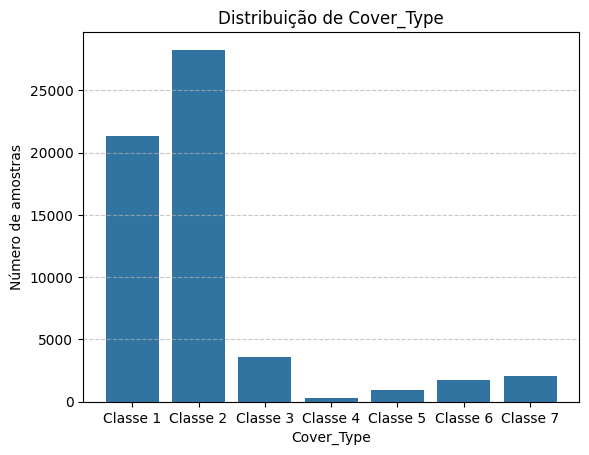

In [227]:
sns.countplot(x=TARGET_COLUMN, data=df)
plt.title('Distribuição de Cover_Type')
plt.xlabel('Cover_Type')
plt.ylabel('Número de amostras')
plt.xticks(ticks=range(0, 7), labels=[f'Classe {i}' for i in range(1, 8)])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.plot()

In [228]:
print(df[TARGET_COLUMN].value_counts().sort_index())

Cover_Type
1    21297
2    28248
3     3607
4      259
5      932
6     1706
7     2052
Name: count, dtype: int64


O dataset é desbalanceado: enquanto as classes 1 e 2 apresentam quantidades maiores do que 20000, as classes seguintes não passam de 5000 unidades.

### <font color='#2D9CDB'>Q12) Gere a correlação entre os atributos e a variável alvo, ordene os valores e plote um gráfico de barras horizontais; destaque, no gráfico, os atributos com maior correlação em valor absoluto utilizando linhas de referência em |r| = 0.2 (valor adotado como um limiar heurístico para indicar correlações moderadas); em seguida, com base nos resultados, identifique quais variáveis podem ser mais relevantes para o modelo. Opcionalmente, pode-se imprimir os valores de correlação para facilitar a verificação numérica dos resultados e complementar a análise visual do gráfico.</font>

In [229]:
var_corr = np.abs(df.corrwith(df[TARGET_COLUMN]).drop(TARGET_COLUMN)).sort_values(ascending=False)
display(var_corr)

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,0
Wilderness_Area4,0.317518
Elevation,0.268264
Soil_Type10,0.236392
Wilderness_Area1,0.200715
Soil_Type39,0.163504
Soil_Type38,0.162663
Horizontal_Distance_To_Roadways,0.155258
Slope,0.145731
Soil_Type22,0.140253
Soil_Type23,0.133668


,0
Wilderness_Area4,0.317518
Elevation,0.268264
Soil_Type10,0.236392
Wilderness_Area1,0.200715


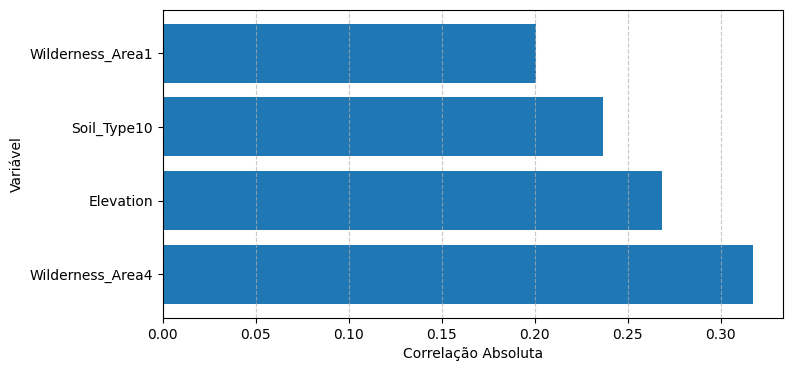

In [230]:
fig, ax = plt.subplots(figsize=(8, 4))
r = 0.2
var_corr = var_corr[np.abs(var_corr) > r]
ax.grid(axis='x', linestyle='--', alpha=0.7)
ax.set_xlabel('Correlação Absoluta')
ax.set_ylabel('Variável')
ax.barh(var_corr.index, var_corr.values)

display(var_corr)

As variáveis que podem ser mais relevantes para a análise do modelo são: Wilderness_Area4, Elevation, Soil_Type10 e Wilderness_Area1.

### <font color='#2D9CDB'>Q13) Aplique a técnica de Análise de Componentes Principais (PCA) para projetar os dados em duas dimensões e gere um gráfico de dispersão (scatter plot) utilizando as duas primeiras componentes principais, colorindo os pontos de acordo com a variável alvo; em seguida, com base na visualização obtida, analise se há separação entre as classes e justifique sua resposta considerando a presença ou não de sobreposição entre os grupos.</font>

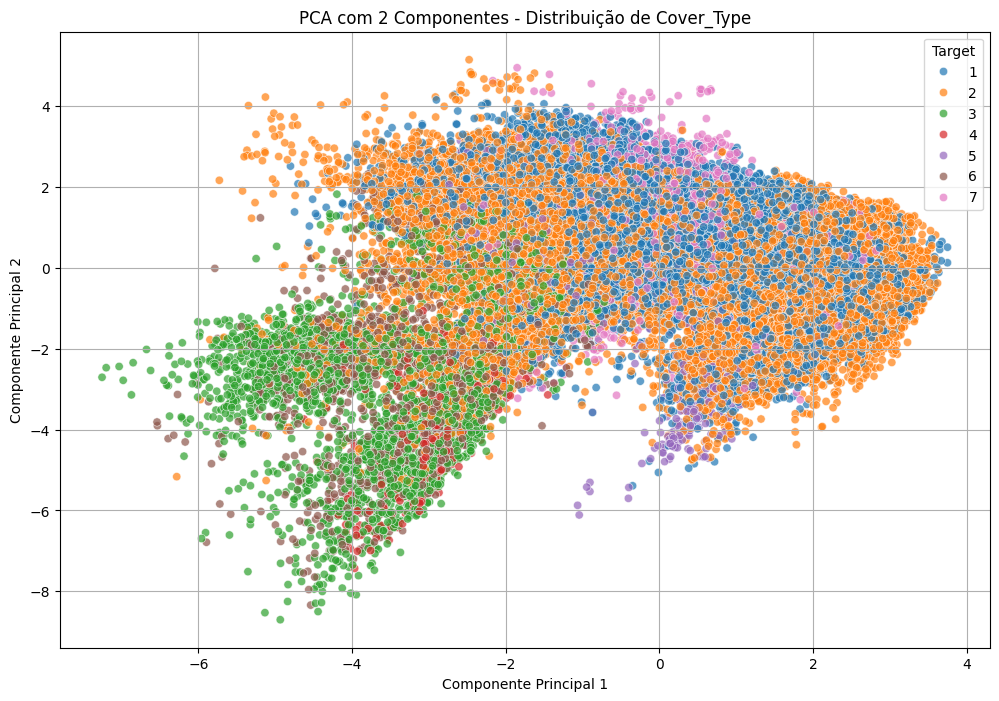

In [231]:
X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]

scaler = StandardScaler()
X = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
pca_df['Target'] = y.reset_index(drop=True)

plt.figure(figsize=(12, 8))
sns.scatterplot(x='PC1', y='PC2', hue='Target', data=pca_df, alpha=0.7, palette='tab10')
plt.title('PCA com 2 Componentes - Distribuição de Cover_Type')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.grid(True)
plt.show()

Pela visualização do gráfico, pode-se notar que há sobreposição dos valores das classes, principalmente no centro do gráfico, em que todas as classes aparecem.

### <font color='#2D9CDB'>Q14) Separe o dataset em variáveis de entrada (`X`) e variável alvo (`y`), divida os dados em conjuntos de treino e teste utilizando `train_test_split` (com 20% para teste) e `random_state=42`, aplique a padronização dos atributos com `StandardScaler` e instancie um objeto de validação cruzada `KFold` com 5 divisões; em seguida, explique por que a validação cruzada (k-fold cross-validation) é importante para avaliar o desempenho de modelos de classificação.</font>

In [232]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

A validação cruzada divide o conjunto de dados em subconjuntos para treinar e validar o modelo múltiplas vezes, alternando as partes de treino e teste, garantindo que todos os dados sejam usados para ambos os fins. A performance final é geralmente a média aritmética dos resultados de cada iteração, e o desvio padrão indica a estabilidade (variância) do modelo.

### <font color='#2D9CDB'>Q15) Utilize o objeto `KFold` instanciado anteriormente para treinar e avaliar um modelo de regressão logística multiclasse ao longo dos 5 folds no conjunto de treino, aplicando a padronização dentro de cada fold; durante o treinamento, exiba o número de iterações (`n_iter_`) em cada fold e verifique se o modelo convergiu corretamente; em seguida, reporte a média das métricas obtidas e descreva o papel do modelo no contexto do problema e o que ele está aprendendo a partir dos dados.</font>

In [233]:
kfold_scores = []
for train_index, test_index in kf.split(X_train):

    X_train_fold, X_test_fold = X_train[train_index], X_train[test_index]
    y_train_fold, y_test_fold = y_train.iloc[train_index], y_train.iloc[test_index]

    # Padronização:
    scaler = StandardScaler()
    X_train_fold = scaler.fit_transform(X_train_fold)
    X_test_fold = scaler.transform(X_test_fold)

    model = LogisticRegression(max_iter=1000)
    model.fit(X_train_fold, y_train_fold)
    kfold_scores.append(model.score(X_test_fold, y_test_fold))

print(f'Número de iterações: {model.n_iter_} até a convergência')
print('-'*45)
print(f'Média: {np.mean(kfold_scores)}')
print(f'Desvio padrão: {np.std(kfold_scores)}')


Número de iterações: [222] até a convergência
---------------------------------------------
Média: 0.7260327022375216
Desvio padrão: 0.003898484192067022


O objetivo principal é encontrar uma relação entre as variáveis explicativas (features) e a variável resposta categórica. Calculando a probabilidade de um novo dado pertencer a cada uma das classes possíveis. Durante o treinamento, o modelo não aprende regras explícitas, mas sim parâmetros estatísticos por meio dos pesos e o viés (bias) para cada classe, ajustando a inclinação da fronteira de decisão para maximizar a separação entre elas. No contexto da Floresta Roosevelt, ele serve para automatizar o mapeamento de áreas onde o acesso humano é difícil, permitindo que o serviço florestal identifique a vegetação sem precisar enviar equipes de campo.

### <font color='#2D9CDB'>Q16) Treine um modelo final de regressão logística utilizando todo o conjunto de treino (`X_train`, `y_train`), aplicando regularização L2 (padrão do `scikit-learn`) com `C=0.01`; em seguida, aplique a padronização adequada e utilize o modelo para calcular as probabilidades previstas no conjunto de teste (`predict_proba`); exiba algumas dessas probabilidades e interprete os valores obtidos, explicando o que cada coluna representa e analisando se o modelo está fazendo previsões com alta ou baixa confiança.</font>

In [234]:
model_l2 = LogisticRegression(penalty='l2', C=0.01, max_iter=1000)
model_l2.fit(X_train, y_train)
proba_L2 = model_l2.predict_proba(X_test)

display(proba_L2)

array([[4.56718497e-01, 5.23084168e-01, 6.39284511e-05, ...,
        3.08497073e-03, 8.75511197e-05, 1.68706108e-02],
       [3.83918004e-02, 4.50020778e-01, 1.52923986e-01, ...,
        1.32717941e-02, 3.44410308e-01, 5.30037820e-04],
       [2.24398122e-01, 7.34051472e-01, 3.88706014e-03, ...,
        2.16104450e-02, 1.14592300e-02, 4.26364116e-03],
       ...,
       [1.19071961e-01, 8.67392084e-01, 2.72070153e-03, ...,
        6.70775343e-03, 2.59867599e-03, 1.45669949e-03],
       [6.23049062e-02, 6.42571002e-01, 1.29042873e-02, ...,
        1.69873219e-01, 1.10630489e-01, 7.63591122e-04],
       [5.11975227e-01, 4.81655132e-01, 1.40019503e-04, ...,
        5.07552887e-03, 1.01168457e-04, 1.02821784e-03]])


Cada coluna representa a probabilidade de uma amostra pertencer a uma das classes (Cover_Type 1 a 7). Observando os valores, para algumas amostras, uma classe tem uma probabilidade significativamente maior (próxima de 1), indicando alta confiança. Para outras, as probabilidades estão mais distribuídas, sugerindo baixa confiança do modelo em relação a qual classe a amostra pertence.

### <font color='#2D9CDB'>Q17) Treine um modelo de regressão logística sem regularização (`penalty=None`) utilizando o mesmo procedimento de padronização e conjunto de treino; em seguida, calcule as probabilidades previstas no conjunto de teste (`predict_proba`), exiba algumas delas (usando os mesmos índices de amostras da questão anterior) e analise os resultados novamente.</font>

In [235]:
model_none = LogisticRegression(penalty=None, max_iter=1000)
model_none.fit(X_train, y_train)
proba_None = model_none.predict_proba(X_test)

display(proba_None)

array([[4.77519750e-01, 5.12781609e-01, 1.33466798e-08, ...,
        1.64641755e-03, 5.07712735e-09, 8.05218592e-03],
       [3.09560411e-02, 4.29105578e-01, 1.08199873e-01, ...,
        1.29401601e-02, 4.18796607e-01, 2.90608369e-09],
       [1.99413962e-01, 7.75334350e-01, 8.77942167e-04, ...,
        2.29376339e-02, 1.35551674e-03, 7.99750343e-05],
       ...,
       [9.52061447e-02, 8.92581514e-01, 2.10580798e-03, ...,
        8.65162105e-03, 1.43589529e-03, 1.87996193e-05],
       [4.83079067e-02, 6.22867851e-01, 6.98584398e-03, ...,
        1.80566713e-01, 1.41267971e-01, 3.12336285e-07],
       [4.81283625e-01, 5.12661562e-01, 4.84706907e-08, ...,
        5.95378622e-03, 8.50616105e-09, 1.00969821e-04]])

A interpretação da confiança do modelo é similar: valores próximos a 1 em uma única classe indicam alta confiança, enquanto probabilidades mais distribuídas sugerem baixa confiança do modelo. Pode-se notar que em geral, as maiores probabilidades se encontram nas duas primeiras classes (o que faz sentido, já que maior parte das amostras realmente pertencem às duas primeiras classes).

### <font color='#2D9CDB'>Q18) Compare as probabilidades previstas pelos modelos com e sem regularização e analise as diferenças observadas, considerando: (i) a concentração das probabilidades em uma única classe, (ii) o nível de confiança das previsões e (iii) possíveis indícios de overfitting; para apoiar sua análise, calcule a confiança média dos modelos (considerando, para cada amostra, a maior probabilidade prevista) e utilize esse valor na comparação.</font>

In [236]:
proba_positiva_l2 = np.max(proba_L2, axis=1)
proba_positiva_none = np.max(proba_None, axis=1)
print(f'Média com regularização: {np.mean(proba_positiva_l2)}')
print(f'Média sem regularização: {np.mean(proba_positiva_none)}')

Média com regularização: 0.7024909004087745
Média sem regularização: 0.7273088311905203


De forma geral, valores maiores de média indicam modelos com maior confiança. Entretanto, uma confiança alta em um modelo sem regularização pode ser um sinal de overfitting, onde o modelo decorou o ruído dos dados de treino e pode estar superestimando sua certeza. A regularização L2 geralmente ajuda a mitigar o overfitting ao penalizar coeficientes grandes, o que leva a um modelo mais simples e menos propenso a se ajustar demais aos dados de treino, resultando em previsóes mais generalizáveis, ainda que com uma confiança média ligeiramente menor. Isso também afeta a densidade de probabilidades das classes, no sentido de que a regularização geralmente não força o modelo a ter certeza absoluta sobre uma única classe, ela incentiva uma distribuição de probabilidade mais balanceada, especialmente quando o modelo não tem um sinal muito forte para uma única classe.

### <font color='#2D9CDB'>Q19) Utilize o `classification_report` para avaliar o desempenho dos modelos com e sem regularização no conjunto de teste; em seguida, compare os resultados obtidos, analisando as métricas de precisão, recall e F1-score para cada classe e discutindo possíveis diferenças no desempenho entre os modelos.</font>

In [239]:
y_pred_l2 = model_l2.predict(X_test)
y_pred_none = model_none.predict(X_test)

# Classification Report para cada classe:
report_l2_classes = classification_report(y_test, y_pred_l2, zero_division=0, output_dict=True)
report_none_classes = classification_report(y_test, y_pred_none, zero_division=0, output_dict=True)

print("\nClassification Report (Regularização L2) por Classe:")
print(pd.DataFrame(report_l2_classes).transpose())
print("\nClassification Report (Sem Regularização) por Classe:")
print(pd.DataFrame(report_none_classes).transpose())


Classification Report (Regularização L2) por Classe:
              precision    recall  f1-score       support
1              0.711760  0.696373  0.703983   4163.000000
2              0.753289  0.805348  0.778449   5759.000000
3              0.617108  0.841667  0.712103    720.000000
4              0.400000  0.109091  0.171429     55.000000
5              1.000000  0.005618  0.011173    178.000000
6              0.512500  0.120944  0.195704    339.000000
7              0.670927  0.515971  0.583333    407.000000
accuracy       0.722915  0.722915  0.722915      0.722915
macro avg      0.666512  0.442144  0.450882  11621.000000
weighted avg   0.722173  0.722915  0.709204  11621.000000

Classification Report (Sem Regularização) por Classe:
              precision    recall  f1-score       support
1              0.708414  0.699736  0.704048   4163.000000
2              0.756788  0.803438  0.779415   5759.000000
3              0.642697  0.794444  0.710559    720.000000
4              0.5757

A regularização L2 não resolve o problema central, que é o desbalanceamento extremo das classes. As diferenças entre os modelos são marginais.

### <font color='#2D9CDB'>Q20) Calcule a matriz de confusão normalizada (por linha, com duas casas de precisão) para os modelos com e sem regularização no conjunto de teste; em seguida, plote ambas as matrizes e compare os resultados, analisando quais classes são melhor classificadas, quais apresentam maior confusão e como a regularização impacta o desempenho entre as classes.</font>

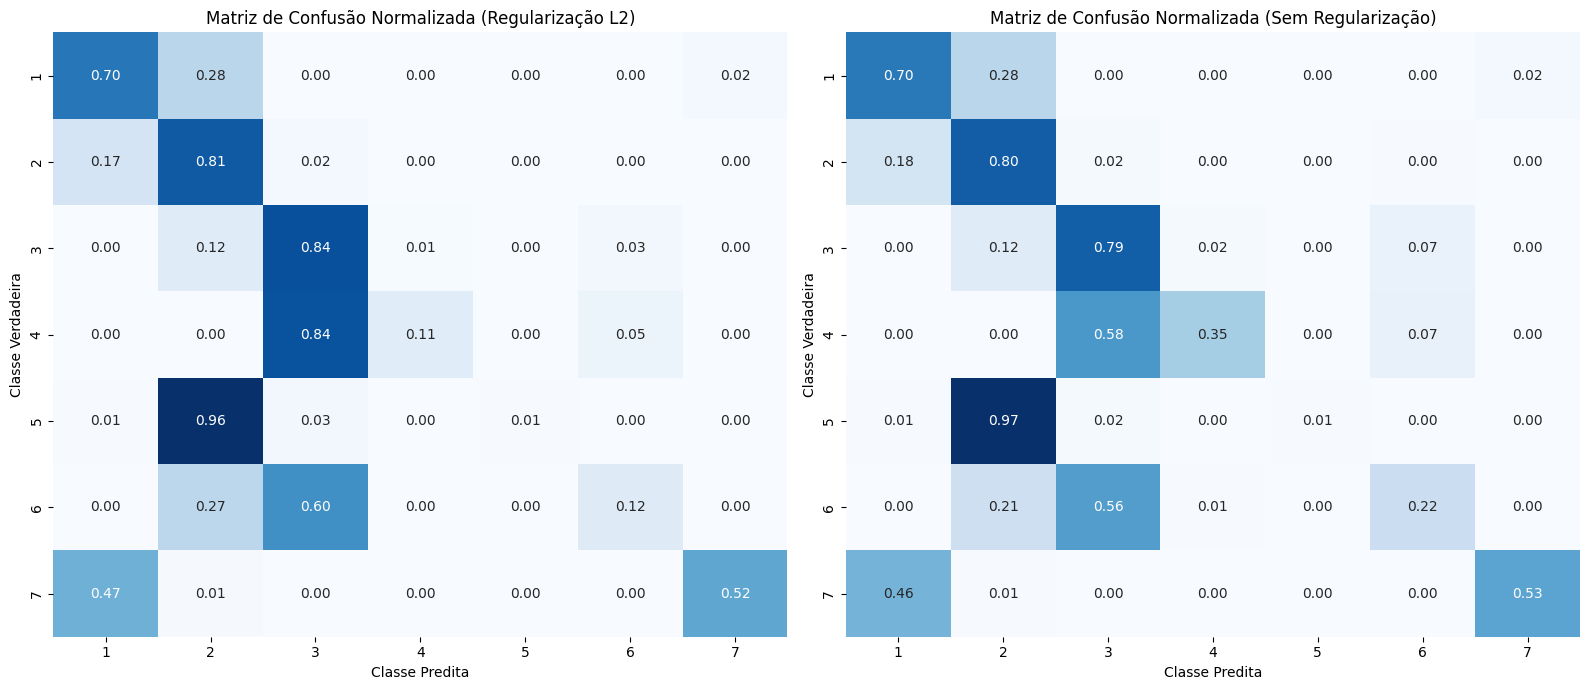

In [249]:
conf_matrix_l2_normalized = confusion_matrix(y_test, y_pred_l2, normalize='true')
conf_matrix_none_normalized = confusion_matrix(y_test, y_pred_none, normalize='true')

conf_matrix_l2_normalized = np.nan_to_num(conf_matrix_l2_normalized)
conf_matrix_none_normalized = np.nan_to_num(conf_matrix_none_normalized)

classes = [1, 2, 3, 4, 5, 6, 7]

plt.figure(figsize=(16, 7))

plt.subplot(1, 2, 1)
sns.heatmap(conf_matrix_l2_normalized, annot=True, fmt='.2f', cmap='Blues', cbar=False,
            xticklabels=classes, yticklabels=classes)
plt.title('Matriz de Confusão Normalizada (Regularização L2)')
plt.xlabel('Classe Predita')
plt.ylabel('Classe Verdadeira')

plt.subplot(1, 2, 2)
sns.heatmap(conf_matrix_none_normalized, annot=True, fmt='.2f', cmap='Blues', cbar=False,
            xticklabels=classes, yticklabels=classes)
plt.title('Matriz de Confusão Normalizada (Sem Regularização)')
plt.xlabel('Classe Predita')
plt.ylabel('Classe Verdadeira')

plt.tight_layout()
plt.show()

Para a análise da matriz de confusão, podemos observar a distribuição das previsões em relação às classes reais. Uma matriz de confusão ideal teria valores altos na diagonal principal (previsões corretas) e valores próximos de zero fora da diagonal. A normalização por linha ajuda a entender a proporção de cada classe real que foi corretamente classificada ou confundida com outras classes. Como o desbalanceamento é severo, a regularização pode piorar ao invés de melhorar o modelo, como pode ser observado com a classe 4.